In [18]:
import geopandas as gpd
import os

In [19]:
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std',  'eccentricity', 'solidity',
        'mean_intensity', 'perimeter', 'compactness', 'shape_index','area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']

target = 'OBSERV_GROUP'

label_map = {
    '0' : 'Building',
    '11' : 'Urban',
    '12' : 'Highway',
    '21' : 'Seasonal crops',
    '22' : 'Permanent crops',
    '23' : 'Pasture',
    '31' : 'Forest',
    '32' : 'Grassland',
    '33' : 'Bare areas',
    '51' : 'Water'
}

In [20]:
train_gdf = gpd.read_file(os.path.join(os.getcwd(),'..','data','geojson','train_files.geojson'))

test_gdf = gpd.read_file(os.path.join(os.getcwd(),'..','data','geojson','test_files.geojson'))

print(train_gdf.columns)

Index(['CODIGO', 'OBSERV', 'INSUMO', 'APOYO', 'ASIGNACION', 'Asignado', 'OAM',
       'area', 'url_type', 'download_url', 'poly_id', 'image_uid', 'r_mean',
       'r_median', 'r_std', 'r_var', 'g_mean', 'g_median', 'g_std', 'g_var',
       'b_mean', 'b_median', 'b_std', 'b_var', 'eccentricity', 'solidity',
       'mean_intensity', 'perimeter', 'compactness', 'shape_index',
       'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity',
       'CODIGO_GROUP', 'geometry'],
      dtype='object')


In [21]:

train_gdf['OBSERV_GROUP'] = train_gdf['CODIGO_GROUP'].replace(label_map)

test_gdf['OBSERV_GROUP'] = test_gdf['CODIGO_GROUP'].replace(label_map)

X_train = train_gdf[features]
y_train = train_gdf[target]
X_test = test_gdf[features]
y_test = test_gdf[target]

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def compute_accuracy(classifier, X, y, train_gdf):
    """Computes the overall accuracy and classification report of the classifier on the given data.

    Args:
        classifier (_classifier_): Trained classifier.
        X (_type_): Features.
        y (_type_): True labels.
        train_gdf (_type_): Training GeoDataFrame for label extraction.
        
    Returns:
        overall_accuracy (float): Overall accuracy of the classifier.
        classification_accuracy (str): Classification report as a string.
    """
    y_pred = classifier.predict(X)
    overall_accuracy = accuracy_score(y, y_pred)
    classification_accuracy= classification_report(y, y_pred,zero_division=1)
    
    labels = list(train_gdf['OBSERV_GROUP'].unique())

    cm = confusion_matrix(y, y_pred, labels=labels)

    cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels, )
    
    cm_norm = confusion_matrix(y, y_pred, labels=labels, normalize='true')
    
    cmd_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)

    # Add gaps between the two plots
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.4})
    cmd.plot(ax=ax[0], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    cmd_norm.plot(ax=ax[1], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    ax[0].set_title('Confusion Matrix')
    ax[1].set_title('Normalized Confusion Matrix')
    plt.show()
    return overall_accuracy, classification_accuracy 


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

def rf_hyperparameter_tuning(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [20, 30, 40],
        'min_samples_split': [2, 4, 6],
        'class_weight':['balanced','balanced_subsample', None], # source for this hyper param tuning : https://www.geeksforgeeks.org/machine-learning/bagging-and-random-forest-for-imbalanced-classification/
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=cv,
        n_jobs=-1,
        verbose=2,
        scoring='f1_macro'
    )
    grid_search_rf.fit(X_train, y_train)
    return grid_search_rf

In [32]:
grid_search_rf= rf_hyperparameter_tuning(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END class_weight=balanced, max_depth=20, min_samples_split=4, n_estimators=100; total time=   0.4s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=4, n_estimators=100; total time=   0.6s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=4, n_estimators=100; total time=   0.5s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=6, n_estimators=100; total time=   0.4s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=6, n_estimators=100; total time=   0.4s
[C

Best Hyperparameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 6, 'n_estimators': 200}
0.49 f1_macro with a standard deviation of 0.02
0.49 f1_macro with a standard deviation of 0.02


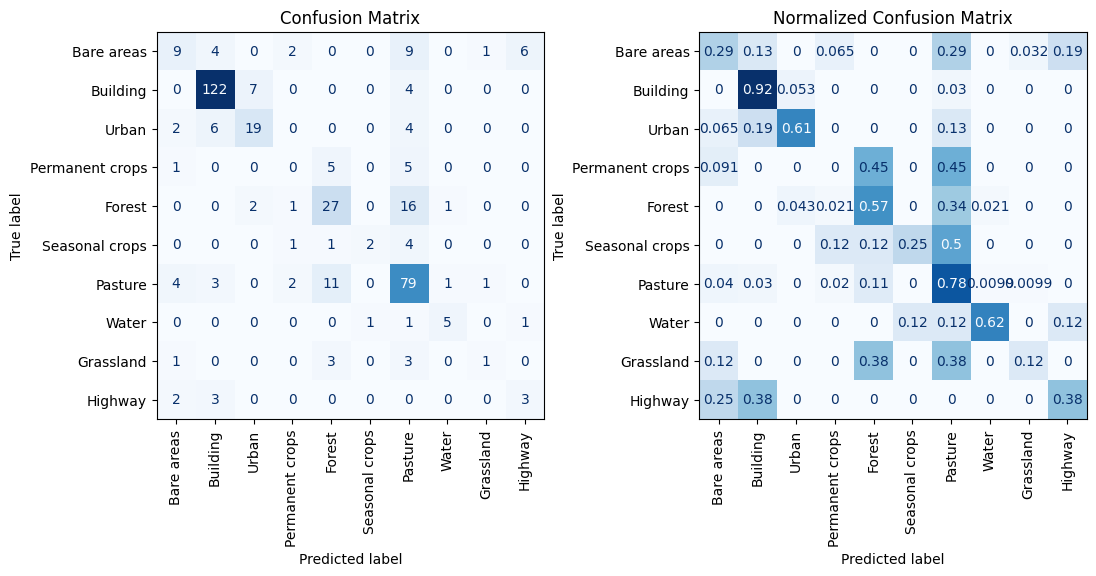

Overall Accuracy after Hyperparameter Tuning: 0.6917098445595855
                 precision    recall  f1-score   support

     Bare areas       0.47      0.29      0.36        31
       Building       0.88      0.92      0.90       133
         Forest       0.57      0.57      0.57        47
      Grassland       0.33      0.12      0.18         8
        Highway       0.30      0.38      0.33         8
        Pasture       0.63      0.78      0.70       101
Permanent crops       0.00      0.00      0.00        11
 Seasonal crops       0.67      0.25      0.36         8
          Urban       0.68      0.61      0.64        31
          Water       0.71      0.62      0.67         8

       accuracy                           0.69       386
      macro avg       0.53      0.46      0.47       386
   weighted avg       0.67      0.69      0.68       386



In [24]:

best_model_rf = grid_search_rf.best_estimator_
print("Best Hyperparameters:", grid_search_rf.best_params_)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model_rf, X_train, y_train, cv=5, scoring='f1_macro')

print("%0.2f f1_macro with a standard deviation of %0.2f" % (scores.mean(), scores.std()))


overall,classification = compute_accuracy(best_model_rf, X_test, y_test, train_gdf)
print("Overall Accuracy after Hyperparameter Tuning:", overall)
print(classification)


In [38]:
import pandas as pd 

def plot_rf_feature_importances(model):
    mdi_importances = pd.Series(
        model.feature_importances_, index=features
    ).sort_values(ascending=True)
    ax = mdi_importances.plot.barh()
    ax.set_title("Random Forest Feature Importances (MDI)")
    ax.figure.tight_layout()
    return mdi_importances

In [10]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'poly']
}

cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svm,
    cv=cv_svm,
    n_jobs=-1,
    verbose=2,
    scoring='f1_macro'
)
grid_search_svm.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END .....................C=0.1, gamma=auto, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.1s
[CV] END .....................C=0.1, gamma=auto, kernel=poly; total time=   0.1s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.1s
[CV] END .......................C=1, gamma=scale

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'poly']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


Best Hyperparameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


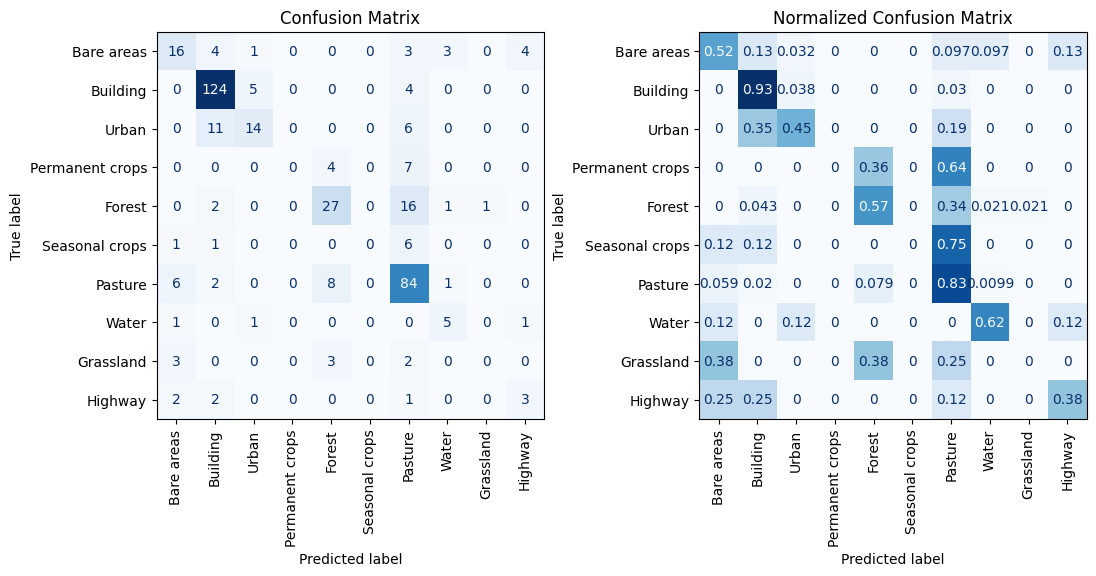

Overall Accuracy for SVM after Hyperparameter Tuning: 0.7072538860103627
                 precision    recall  f1-score   support

     Bare areas       0.55      0.52      0.53        31
       Building       0.85      0.93      0.89       133
         Forest       0.64      0.57      0.61        47
      Grassland       0.00      0.00      0.00         8
        Highway       0.38      0.38      0.38         8
        Pasture       0.65      0.83      0.73       101
Permanent crops       1.00      0.00      0.00        11
 Seasonal crops       1.00      0.00      0.00         8
          Urban       0.67      0.45      0.54        31
          Water       0.50      0.62      0.56         8

       accuracy                           0.71       386
      macro avg       0.62      0.43      0.42       386
   weighted avg       0.71      0.71      0.68       386



In [11]:
best_model_svm = grid_search_svm.best_estimator_
print("Best Hyperparameters for SVM:", grid_search_svm.best_params_)
overall_svm,classification_svm = compute_accuracy(best_model_svm, X_test_scaled, y_test, train_gdf)
print("Overall Accuracy for SVM after Hyperparameter Tuning:", overall_svm)
print(classification_svm)

In [ ]:
from sklearn.dummy import DummyClassifier

def compare_with_baseline(estimator, X_train, y_train, X_test, y_test, model_name="Model"):
    strategies = ['most_frequent', 'stratified', 'uniform'] # uniform : each class has equal proabibility to appear , stratified : 
    results = []
    
    for strategy in strategies:
        dummy = DummyClassifier(strategy=strategy, random_state=42)
        dummy.fit(X_train, y_train)
        dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
        results.append({'Model': f'Dummy ({strategy})', 'Overall Test Accuracy': dummy_acc})
    
    model_acc = accuracy_score(y_test, estimator.predict(X_test))
    results.append({'Model': model_name, 'Overall Test Accuracy': model_acc})
    
    df = pd.DataFrame(results)
    print(df.to_string(index=False))
    return df

In [17]:
print("Random Forest vs Baseline:")
compare_with_baseline(best_model_rf, X_train, y_train, X_test, y_test, "Random Forest")

print("\nSVM vs Baseline:")
compare_with_baseline(best_model_svm, X_train_scaled, y_train, X_test_scaled, y_test, "SVM")

Random Forest vs Baseline:
                Model  Overall Test Accuracy
Dummy (most_frequent)               0.344560
   Dummy (stratified)               0.199482
      Dummy (uniform)               0.088083
        Random Forest               0.689119

SVM vs Baseline:
                Model  Overall Test Accuracy
Dummy (most_frequent)               0.344560
   Dummy (stratified)               0.199482
      Dummy (uniform)               0.088083
                  SVM               0.707254


,Model,Overall Test Accuracy
0,Dummy (most_frequent),0.344560
1,Dummy (stratified),0.199482
2,Dummy (uniform),0.088083
3,SVM,0.707254


In [28]:
# test with random forest imbalance handling 

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=4, n_estimators=100; total time=   0.1s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=4, n_estimators=100; total time=   0.1s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=4, n_estimators=100; total time=   0.1s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=4, n_estimators=100; total time=   0.1s
[C

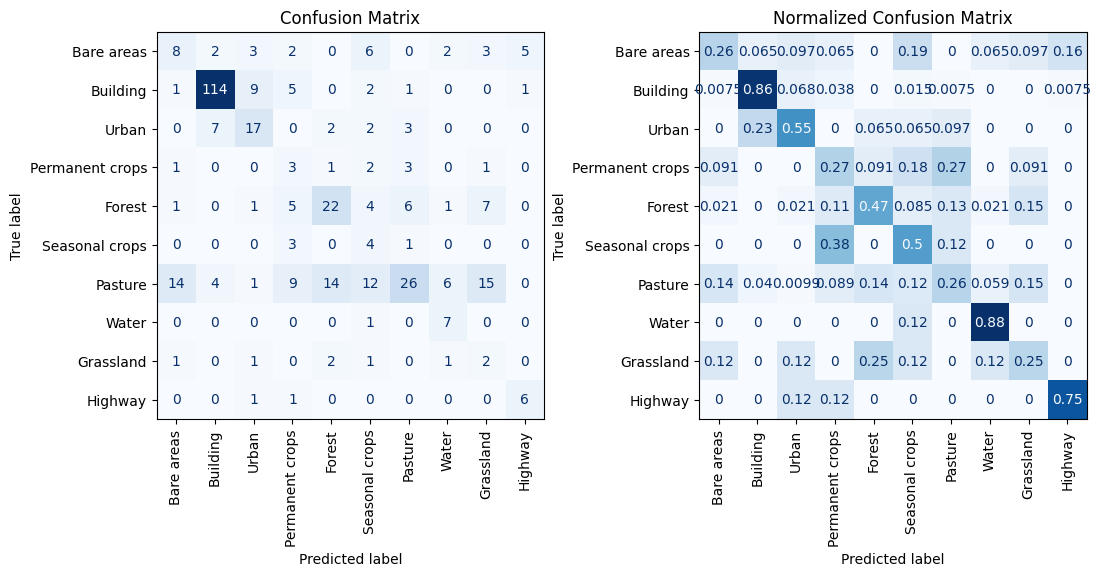

Overall Accuracy after Hyperparameter Tuning: 0.5414507772020726
                 precision    recall  f1-score   support

     Bare areas       0.31      0.26      0.28        31
       Building       0.90      0.86      0.88       133
         Forest       0.54      0.47      0.50        47
      Grassland       0.07      0.25      0.11         8
        Highway       0.50      0.75      0.60         8
        Pasture       0.65      0.26      0.37       101
Permanent crops       0.11      0.27      0.15        11
 Seasonal crops       0.12      0.50      0.19         8
          Urban       0.52      0.55      0.53        31
          Water       0.41      0.88      0.56         8

       accuracy                           0.54       386
      macro avg       0.41      0.50      0.42       386
   weighted avg       0.64      0.54      0.56       386



In [34]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

grid_search_rf= rf_hyperparameter_tuning(X_train_resampled, y_train_resampled)

print("Best Hyperparameters with Random Under Sampling:", grid_search_rf.best_params_)
overall,classification = compute_accuracy(grid_search_rf.best_estimator_, X_test, y_test, train_gdf)
print("Overall Accuracy after Hyperparameter Tuning:", overall)
print(classification)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END class_weight=balanced, max_depth=20, min_samples_split=4, n_estimators=100; total time=   1.4s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=4, n_estimators=100; total time=   1.6s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=6, n_estimators=100; total time=   1.6s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   1.7s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   1.7s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   1.7s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=2, n_estimators=100; total time=   1.8s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=4, n_estimators=100; total time=   1.7s
[CV] END class_weight=balanced, max_depth=20, min_samples_split=4, n_estimators=100; total time=   1.7s
[C

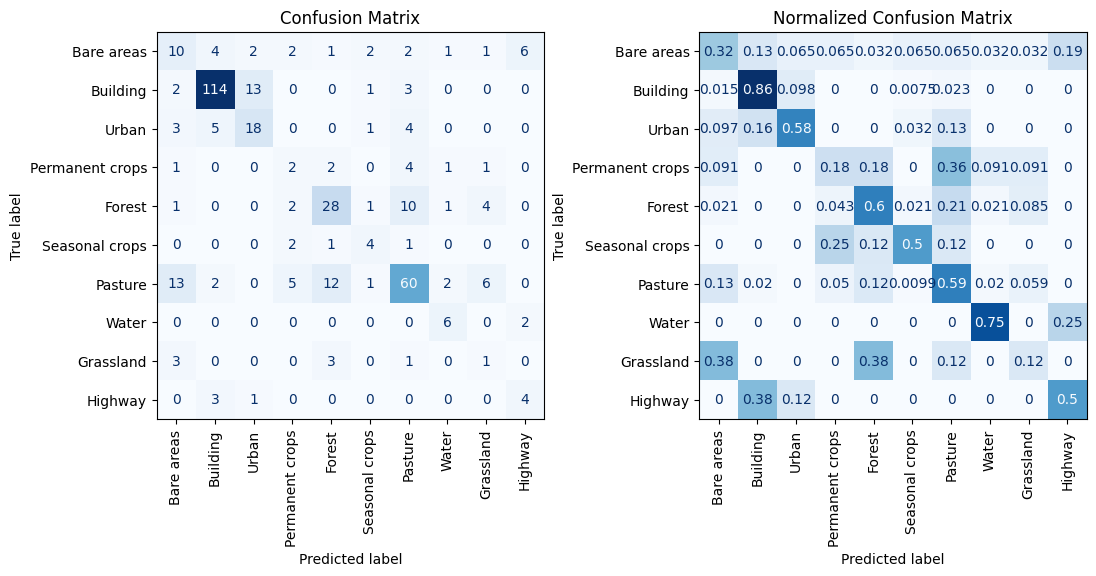

Overall Accuracy after Hyperparameter Tuning: 0.6398963730569949
                 precision    recall  f1-score   support

     Bare areas       0.30      0.32      0.31        31
       Building       0.89      0.86      0.87       133
         Forest       0.60      0.60      0.60        47
      Grassland       0.08      0.12      0.10         8
        Highway       0.33      0.50      0.40         8
        Pasture       0.71      0.59      0.65       101
Permanent crops       0.15      0.18      0.17        11
 Seasonal crops       0.40      0.50      0.44         8
          Urban       0.53      0.58      0.55        31
          Water       0.55      0.75      0.63         8

       accuracy                           0.64       386
      macro avg       0.45      0.50      0.47       386
   weighted avg       0.66      0.64      0.65       386



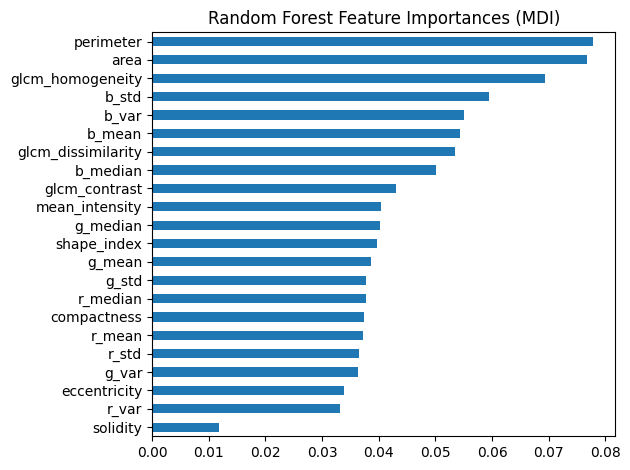

In [39]:
from imblearn.over_sampling import SMOTE # source : https://medium.com/sfu-cspmp/surviving-in-a-random-forest-with-imbalanced-datasets-b98b963d52eb

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

grid_search_rf= rf_hyperparameter_tuning(X_train_resampled, y_train_resampled)

print("Best Hyperparameters with SMOTE:", grid_search_rf.best_params_)
overall,classification = compute_accuracy(grid_search_rf.best_estimator_, X_test, y_test, train_gdf)
print("Overall Accuracy after Hyperparameter Tuning:", overall)
print(classification)
_ = plot_rf_feature_importances(grid_search_rf.best_estimator_)
